STEP 0 : THE LOAN APPROVAL DATASET
    Income CreditScore Employment DebtLevel Collateral Approved
0     High        Good     Stable       Low        Yes      Yes
1     High        Good     Stable    Medium         No      Yes
2     High        Good        New       Low         No      Yes
3     High        Good     Stable      High        Yes      Yes
4   Medium        Good     Stable       Low         No      Yes
5   Medium        Good     Stable    Medium        Yes      Yes
6   Medium        Good     Stable      High        Yes      Yes
7      Low        Good     Stable       Low        Yes      Yes
8      Low        Good        New    Medium        Yes      Yes
9     High        Poor     Stable       Low        Yes       No
10  Medium        Poor     Stable       Low        Yes       No
11     Low        Poor        New      High         No       No
12  Medium     Average        New      High         No       No
13     Low     Average     Stable      High         No       No
14   

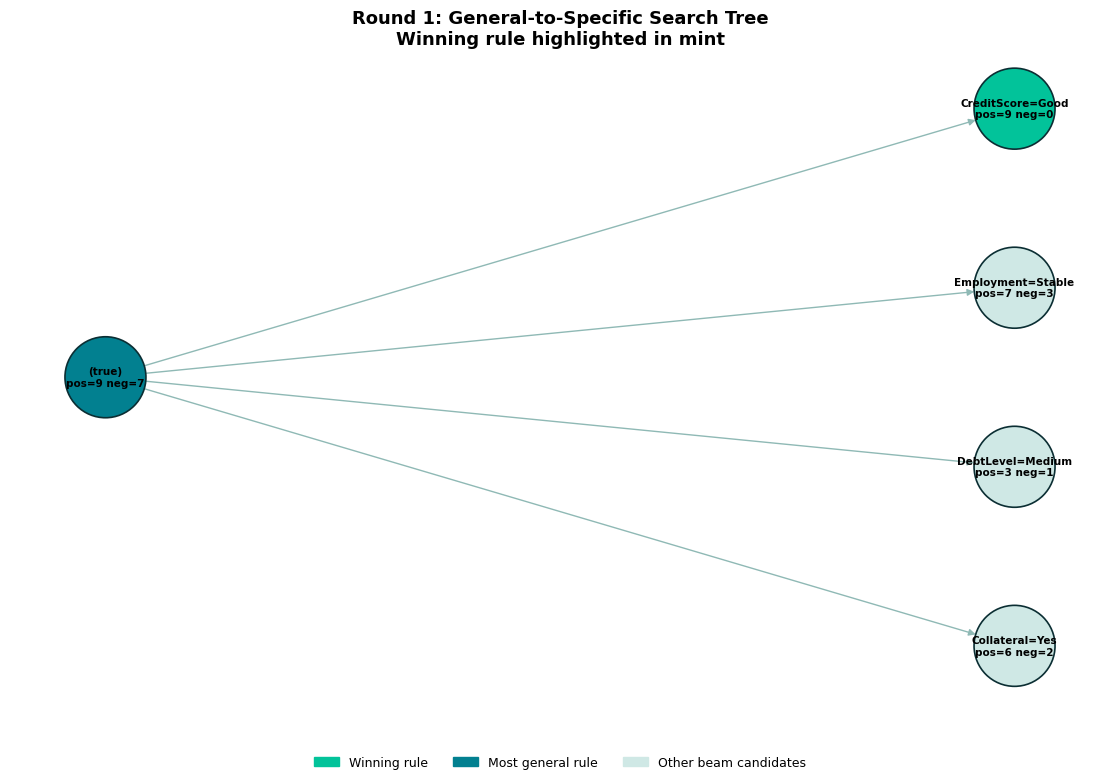

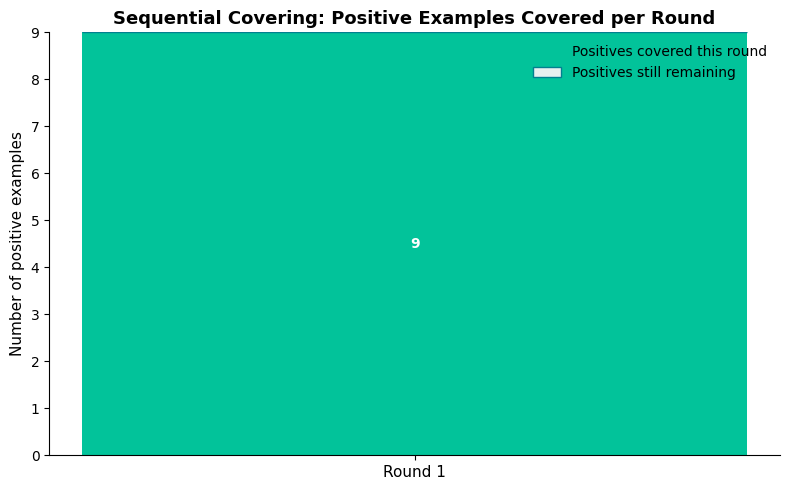

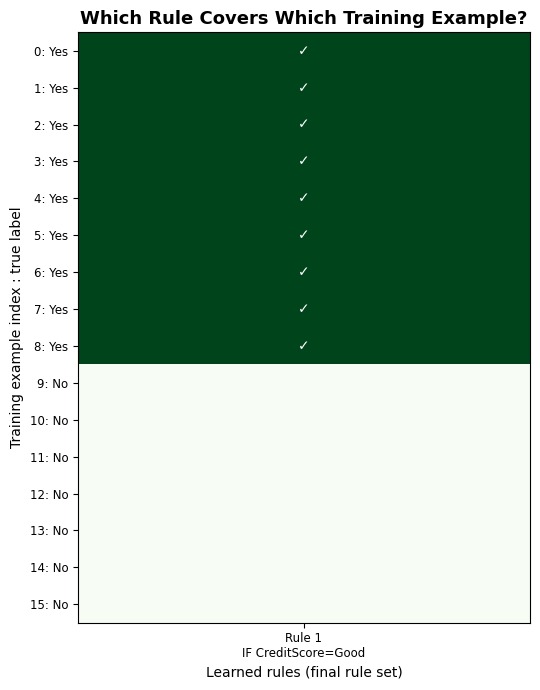

In [1]:
"""
Sequential Covering Algorithm — New Dataset: Loan Approval
===========================================================
Same Sequential Covering + General-to-Specific Beam Search approach,
but using a new categorical Loan Approval dataset instead of EnjoySport.

The notebook will:
  1. Print the Loan Approval dataset
  2. Run LEARN-ONE-RULE using general-to-specific BEAM SEARCH
  3. Run SEQUENTIAL-COVERING until all positive examples are covered
  4. Display:
       - Search tree for each round
       - Positive coverage bar chart
       - Final rule coverage heatmap
"""

!pip install networkx -q

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# ------------------------------------------------------------------
# 1. NEW DATASET: LOAN APPROVAL
# ------------------------------------------------------------------
columns = [
    "Income", "CreditScore", "Employment", "DebtLevel",
    "Collateral", "Approved"
]

data = [
    # ---- Positives intended for Rule 1: High income + Good credit ----
    ["High",   "Good",    "Stable",   "Low",    "Yes", "Yes"],
    ["High",   "Good",    "Stable",   "Medium", "No",  "Yes"],
    ["High",   "Good",    "New",      "Low",    "No",  "Yes"],
    ["High",   "Good",    "Stable",   "High",   "Yes", "Yes"],

    # ---- Positives intended for Rule 2: Medium income + Good credit + Stable employment ----
    ["Medium", "Good",    "Stable",   "Low",    "No",  "Yes"],
    ["Medium", "Good",    "Stable",   "Medium", "Yes", "Yes"],
    ["Medium", "Good",    "Stable",   "High",   "Yes", "Yes"],

    # ---- Positives intended for Rule 3: Low income + Good credit + Collateral ----
    ["Low",    "Good",    "Stable",   "Low",    "Yes", "Yes"],
    ["Low",    "Good",    "New",      "Medium", "Yes", "Yes"],

    # ---- Negative examples ----
    ["High",   "Poor",    "Stable",   "Low",    "Yes", "No"],
    ["Medium", "Poor",    "Stable",   "Low",    "Yes", "No"],
    ["Low",    "Poor",    "New",      "High",   "No",  "No"],
    ["Medium", "Average", "New",      "High",   "No",  "No"],
    ["Low",    "Average", "Stable",   "High",   "No",  "No"],
    ["High",   "Average", "New",      "High",   "No",  "No"],
    ["Medium", "Poor",    "New",      "Medium", "No",  "No"],
]

df = pd.DataFrame(data, columns=columns)

TARGET_ATTR = "Approved"
TARGET_VAL = "Yes"
ATTRIBUTES = [c for c in columns if c != TARGET_ATTR]

DOMAIN = {attr: sorted(df[attr].unique()) for attr in ATTRIBUTES}


def print_dataset():
    print("=" * 78)
    print("STEP 0 : THE LOAN APPROVAL DATASET")
    print("=" * 78)
    print(df.to_string(index=True))

    n_pos = (df[TARGET_ATTR] == TARGET_VAL).sum()
    n_neg = (df[TARGET_ATTR] != TARGET_VAL).sum()

    print(
        f"\nTotal examples: {len(df)}"
        f"   |   Positive (Yes): {n_pos}"
        f"   |   Negative (No): {n_neg}"
    )
    print()


# ------------------------------------------------------------------
# 2. RULE REPRESENTATION & SCORING
# ------------------------------------------------------------------

def covers(rule, row):
    """Return True if a row satisfies every condition in the rule."""
    return all(row[attr] == val for attr, val in rule.items())


def evaluate(rule, examples):
    """Return (positive_covered, negative_covered, precision)."""
    covered = examples[
        examples.apply(lambda r: covers(rule, r), axis=1)
    ]

    pos = (covered[TARGET_ATTR] == TARGET_VAL).sum()
    neg = (covered[TARGET_ATTR] != TARGET_VAL).sum()

    precision = (
        pos / (pos + neg)
        if (pos + neg) > 0
        else 0.0
    )

    return pos, neg, precision


def rule_to_str(rule):
    if not rule:
        return "IF (true)"

    conditions = " AND ".join(
        f"{attr}={value}"
        for attr, value in rule.items()
    )

    return f"IF {conditions}"


# ------------------------------------------------------------------
# 3. LEARN-ONE-RULE: GENERAL-TO-SPECIFIC BEAM SEARCH
# ------------------------------------------------------------------

def learn_one_rule(examples, beam_width=4, max_conditions=None):

    if max_conditions is None:
        max_conditions = len(ATTRIBUTES)

    search_history = []

    # Start from the most general rule
    beam = [{}]

    depth0_pos, depth0_neg, depth0_prec = evaluate({}, examples)

    search_history.append({
        "depth": 0,
        "candidates": [
            ({}, depth0_pos, depth0_neg, depth0_prec, None)
        ],
        "beam": [{}],
    })

    best_rule = {}
    best_pos = depth0_pos
    best_neg = depth0_neg
    best_prec = depth0_prec

    for depth in range(1, max_conditions + 1):

        candidates = []

        for parent in beam:

            used_attrs = set(parent.keys())

            for attr in ATTRIBUTES:

                if attr in used_attrs:
                    continue

                for val in DOMAIN[attr]:

                    child = dict(parent)
                    child[attr] = val

                    pos, neg, prec = evaluate(child, examples)

                    # Ignore rules that cover no positive examples
                    if pos == 0:
                        continue

                    candidates.append(
                        (child, pos, neg, prec, parent)
                    )

        if not candidates:
            break

        # Ranking:
        # 1. Pure rules first
        # 2. Higher precision
        # 3. Higher positive coverage
        candidates.sort(
            key=lambda c: (c[2] == 0, c[3], c[1]),
            reverse=True
        )

        # Keep only the top beam_width candidates
        new_beam = []
        seen = set()

        for child, pos, neg, prec, parent in candidates:

            key = frozenset(child.items())

            if key not in seen:
                seen.add(key)
                new_beam.append(child)

            if len(new_beam) >= beam_width:
                break

        beam = new_beam

        search_history.append({
            "depth": depth,
            "candidates": candidates,
            "beam": beam
        })

        # Stop when a pure rule is found
        pure_candidates = [
            c for c in candidates
            if c[2] == 0
        ]

        if pure_candidates:

            top = pure_candidates[0]

            best_rule = top[0]
            best_pos = top[1]
            best_neg = top[2]
            best_prec = top[3]

            break

        else:

            top = candidates[0]

            if (
                (top[2] == 0, top[3], top[1])
                >
                (best_neg == 0, best_prec, best_pos)
            ):

                best_rule = top[0]
                best_pos = top[1]
                best_neg = top[2]
                best_prec = top[3]

    return (
        best_rule,
        best_pos,
        best_neg,
        best_prec,
        search_history
    )


# ------------------------------------------------------------------
# 4. SEQUENTIAL COVERING
# ------------------------------------------------------------------

def sequential_covering(beam_width=4):

    working = df.copy()

    rules = []
    round_logs = []

    round_num = 1

    while (working[TARGET_ATTR] == TARGET_VAL).sum() > 0:

        rule, pos, neg, prec, history = learn_one_rule(
            working,
            beam_width=beam_width
        )

        covered_mask = working.apply(
            lambda r: covers(rule, r),
            axis=1
        )

        covered_examples = working[covered_mask]

        covered_positive_idx = covered_examples[
            covered_examples[TARGET_ATTR] == TARGET_VAL
        ].index.tolist()

        print(f"--- Round {round_num} ---")

        print(
            f"Remaining positives before this round : "
            f"{(working[TARGET_ATTR] == TARGET_VAL).sum()}"
        )

        print(
            f"Learned rule                           : "
            f"{rule_to_str(rule)}  THEN "
            f"{TARGET_ATTR} = {TARGET_VAL}"
        )

        print(
            f"Covers                                 : "
            f"{pos} positive(s), {neg} negative(s)"
        )

        print(
            f"Positive example indices covered       : "
            f"{covered_positive_idx}"
        )

        print()

        rules.append(rule)

        round_logs.append({
            "round": round_num,
            "rule": rule,
            "pos_covered": pos,
            "neg_covered": neg,
            "covered_positive_idx": covered_positive_idx,
            "history": history,
            "remaining_pos_before":
                (working[TARGET_ATTR] == TARGET_VAL).sum()
        })

        # Remove covered positive examples
        working = working.drop(index=covered_positive_idx)

        round_num += 1

        if pos == 0:
            print(
                "No further progress possible — "
                "stopping to avoid an infinite loop."
            )
            break

    return rules, round_logs


# ------------------------------------------------------------------
# 5. SEARCH TREE GRAPH
# ------------------------------------------------------------------

def plot_search_tree(history, winning_rule, round_num):

    G = nx.DiGraph()

    labels = {}
    node_colors = []
    node_id_of_rule = {}

    def node_id(rule):

        key = frozenset(rule.items())

        if key not in node_id_of_rule:
            node_id_of_rule[key] = f"n{len(node_id_of_rule)}"

        return node_id_of_rule[key]

    root_pos, root_neg, root_prec = (
        history[0]["candidates"][0][1:4]
    )

    root_id = node_id({})

    G.add_node(root_id)

    labels[root_id] = (
        f"(true)\npos={root_pos} neg={root_neg}"
    )

    winning_key = frozenset(winning_rule.items())

    # Only show hypotheses that survived in the beam
    kept_keys = set()

    for level in history:

        for r in level["beam"]:
            kept_keys.add(frozenset(r.items()))

    kept_keys.add(winning_key)

    for level in history[1:]:

        for child, pos, neg, prec, parent in level["candidates"]:

            key = frozenset(child.items())

            if key not in kept_keys:
                continue

            cid = node_id(child)
            pid = node_id(parent)

            if not G.has_node(cid):

                G.add_node(cid)

                label = " ∧ ".join(
                    f"{a}={v}"
                    for a, v in child.items()
                )

                labels[cid] = (
                    f"{label}\npos={pos} neg={neg}"
                )

            G.add_edge(pid, cid)

    for layer, nodes in enumerate(
        nx.bfs_layers(G, root_id)
    ):

        for n in nodes:
            G.nodes[n]["layer"] = layer

    pos_layout = nx.multipartite_layout(
        G,
        subset_key="layer"
    )

    for n in G.nodes():

        key = None

        for k, v in node_id_of_rule.items():

            if v == n:
                key = k
                break

        if key == winning_key:
            node_colors.append("#02C39A")
        elif n == root_id:
            node_colors.append("#028090")
        else:
            node_colors.append("#CFE8E5")

    plt.figure(figsize=(11, 6.5))

    nx.draw(
        G,
        pos_layout,
        labels=labels,
        with_labels=True,
        node_color=node_colors,
        node_size=3400,
        font_size=7.5,
        font_weight="bold",
        arrows=True,
        edge_color="#8FB9B5",
        linewidths=1.2,
        edgecolors="#0B2E33"
    )

    plt.title(
        f"Round {round_num}: General-to-Specific Search Tree\n"
        f"Winning rule highlighted in mint",
        fontsize=13,
        fontweight="bold"
    )

    winner_patch = mpatches.Patch(
        color="#02C39A",
        label="Winning rule"
    )

    root_patch = mpatches.Patch(
        color="#028090",
        label="Most general rule"
    )

    other_patch = mpatches.Patch(
        color="#CFE8E5",
        label="Other beam candidates"
    )

    plt.legend(
        handles=[
            winner_patch,
            root_patch,
            other_patch
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=3,
        frameon=False,
        fontsize=9
    )

    plt.show()


# ------------------------------------------------------------------
# 6. POSITIVE COVERAGE BAR CHART
# ------------------------------------------------------------------

def plot_coverage_bar(round_logs):

    rounds = [
        f"Round {rl['round']}"
        for rl in round_logs
    ]

    covered = [
        rl["pos_covered"]
        for rl in round_logs
    ]

    remaining_after = []

    total_pos = (
        df[TARGET_ATTR] == TARGET_VAL
    ).sum()

    running = total_pos

    for rl in round_logs:

        running -= rl["pos_covered"]

        remaining_after.append(running)

    x = range(len(rounds))

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.bar(
        x,
        covered,
        color="#02C39A",
        label="Positives covered this round"
    )

    ax.bar(
        x,
        remaining_after,
        bottom=covered,
        color="#E8F0EF",
        edgecolor="#028090",
        label="Positives still remaining"
    )

    for i, (c, r) in enumerate(
        zip(covered, remaining_after)
    ):

        ax.text(
            i,
            c / 2,
            str(c),
            ha="center",
            va="center",
            fontweight="bold",
            color="white"
        )

        if r > 0:

            ax.text(
                i,
                c + r / 2,
                str(r),
                ha="center",
                va="center",
                fontweight="bold"
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(rounds, fontsize=11)

    ax.set_ylabel(
        "Number of positive examples",
        fontsize=11
    )

    ax.set_title(
        "Sequential Covering: Positive Examples Covered per Round",
        fontsize=13,
        fontweight="bold"
    )

    ax.legend(
        loc="upper right",
        frameon=False
    )

    ax.spines[
        ["top", "right"]
    ].set_visible(False)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# 7. FINAL COVERAGE HEATMAP
# ------------------------------------------------------------------

def plot_coverage_heatmap(rules):

    n = len(df)
    m = len(rules)

    matrix = [
        [
            1 if covers(rule, df.loc[i]) else 0
            for rule in rules
        ]
        for i in range(n)
    ]

    fig, ax = plt.subplots(
        figsize=(4.5 + m, 7)
    )

    ax.imshow(
        matrix,
        cmap="Greens",
        aspect="auto",
        vmin=0,
        vmax=1
    )

    ax.set_xticks(range(m))

    ax.set_xticklabels(
        [
            f"Rule {i+1}\n{rule_to_str(r)}"
            for i, r in enumerate(rules)
        ],
        fontsize=8.5
    )

    ax.set_yticks(range(n))

    row_labels = [
        f"{i}: {df.loc[i, TARGET_ATTR]}"
        for i in range(n)
    ]

    ax.set_yticklabels(
        row_labels,
        fontsize=8.5
    )

    for i in range(n):

        for j in range(m):

            if matrix[i][j]:

                ax.text(
                    j,
                    i,
                    "✓",
                    ha="center",
                    va="center",
                    color="white",
                    fontweight="bold"
                )

    ax.set_title(
        "Which Rule Covers Which Training Example?",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Learned rules (final rule set)"
    )

    ax.set_ylabel(
        "Training example index : true label"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# MAIN
# ------------------------------------------------------------------

print_dataset()

print("=" * 78)
print("STEP 1 : RUNNING SEQUENTIAL COVERING")
print("=" * 78)

rules, round_logs = sequential_covering(
    beam_width=4
)

print("=" * 78)
print("FINAL LEARNED RULE SET")
print("=" * 78)

for i, r in enumerate(rules, start=1):

    print(
        f"Rule {i}: {rule_to_str(r)}  THEN  "
        f"{TARGET_ATTR} = {TARGET_VAL}"
    )

print()

print("=" * 78)
print("STEP 2 : GENERATING GRAPHS")
print("=" * 78)

for rl in round_logs:

    plot_search_tree(
        rl["history"],
        rl["rule"],
        rl["round"]
    )

plot_coverage_bar(round_logs)
plot_coverage_heatmap(rules)
